# RAF-DB with ResNet-18 + MLP + Affinity Loss

This notebook keeps the idea simple:
- use `ResNet-18` to extract image features
- use a small `MLP` head to classify 7 emotions
- use `CrossEntropyLoss` for prediction
- use `AffinityLoss` to make same-class features closer

It is written as a short, readable baseline with training, evaluation, confusion matrices, and PCA / t-SNE plots.

## 1. Imports

In [78]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Device

In [79]:
SEED = 24520031
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3. Configuration

In [122]:
CONFIG = {
    'raf_path': 'datasets/raf-db',
    'image_size': 224,
    'batch_size': 64,
    'epochs': 30,
    'lr': 1e-4,
    'min_lr': 1e-5,
    'weight_decay': 1e-4,
    'num_workers': 4,
    'num_classes': 7,
    'hidden_dim': 256,
    'dropout': 0.3,
    'lambda_aff': 0.05,
    'plateau_factor': 0.5,
    'plateau_patience': 1,
    'plateau_threshold': 5e-3,
    'backbone_checkpoint': 'models/resnet18_msceleb.pth',
    'train_from_scratch': True,
    'checkpoint_path': 'checkpoints/resnet18_affinity_rafdb_best.pth',
    'max_tsne_samples': 1500,
}

EMOTION_LABELS = {
    0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
    4: 'Sadness', 5: 'Anger', 6: 'Neutral'
}

os.makedirs('checkpoints', exist_ok=True)
pd.Series(CONFIG, name='value').to_frame()

,value
raf_path,datasets/raf-db
image_size,224
batch_size,64
epochs,30
lr,0.0001
min_lr,0.00001
weight_decay,0.0001
num_workers,4
num_classes,7
hidden_dim,256


## 4. Dataset

This notebook uses the Kaggle RAF-DB training split and creates:
- 80% training data
- 20% validation data

The split is stratified so class balance is preserved.

In [81]:
class RAFDBDataset(Dataset):
    def __init__(self, root, split, transform=None):
        root = Path(root)
        csv_path = root / f'{split}_labels.csv'
        image_root = root / split

        df = pd.read_csv(csv_path)
        df.columns = [c.strip().lower() for c in df.columns]
        df['label'] = df['label'].astype(int) - 1
        df['path'] = [image_root / str(label + 1) / image for image, label in zip(df['image'], df['label'])]

        missing = df.loc[~df['path'].map(Path.exists), 'path']
        if len(missing):
            raise FileNotFoundError(f'Missing image example: {missing.iloc[0]}')

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


train_tfms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_train_dataset = RAFDBDataset(CONFIG['raf_path'], 'train', train_tfms)
full_eval_dataset = RAFDBDataset(CONFIG['raf_path'], 'train', eval_tfms)

indices = np.arange(len(full_train_dataset))
labels = full_train_dataset.df['label'].to_numpy()
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=labels
)

train_dataset = Subset(full_train_dataset, train_idx.tolist())
val_dataset = Subset(full_eval_dataset, val_idx.tolist())
center_dataset = Subset(full_eval_dataset, train_idx.tolist())
val_paths = full_eval_dataset.df.iloc[val_idx]['path'].tolist()

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=CONFIG['num_workers'], pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True
)
center_loader = DataLoader(
    center_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True
)

print('Train samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Example validation image:', val_paths[0])

Train samples: 9816
Validation samples: 2455
Example validation image: datasets/raf-db/train/1/train_06640_aligned.jpg


## 5. Model and Loss

The class centers are initialized from the average training features before training starts.

In [123]:
class ResNet18AffinityModel(nn.Module):
    def __init__(self, num_classes=7, hidden_dim=256, dropout=0.3, checkpoint_path=None):
        super().__init__()
        backbone = models.resnet18(weights=None)
        if checkpoint_path:
            checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
            state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
            backbone.load_state_dict(state_dict, strict=True)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        feat = self.encoder(x).flatten(1)
        logits = self.classifier(feat)
        return feat, logits


class AffinityLoss(nn.Module):
    def __init__(self, num_classes=7, feat_dim=512, eps=1e-6):
        super().__init__()
        self.centers = nn.Parameter(torch.zeros(num_classes, feat_dim))
        self.eps = eps

    def forward(self, features, labels):
        batch_centers = self.centers[labels]
        intra = ((features - batch_centers) ** 2).sum(dim=1).mean()
        center_mean = self.centers.mean(dim=0, keepdim=True)
        center_spread = ((self.centers - center_mean) ** 2).sum(dim=1).mean()
        return intra / (center_spread + self.eps)


backbone_checkpoint = Path(CONFIG['backbone_checkpoint'])
if not backbone_checkpoint.is_absolute():
    backbone_checkpoint = Path.cwd() / backbone_checkpoint

model = ResNet18AffinityModel(
    num_classes=CONFIG['num_classes'],
    hidden_dim=CONFIG['hidden_dim'],
    dropout=CONFIG['dropout'],
    checkpoint_path=backbone_checkpoint,
).to(device)

affinity_loss = AffinityLoss(CONFIG['num_classes'], 512).to(device)
ce_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(affinity_loss.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
 )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=CONFIG['plateau_factor'],
    patience=CONFIG['plateau_patience'],
    threshold=CONFIG['plateau_threshold'],
    # cooldown=CONFIG['plateau_cooldown'],
    min_lr=CONFIG['min_lr'],
)

@torch.no_grad()
def init_centers(loader):
    model.eval()
    sums = torch.zeros(CONFIG['num_classes'], 512, device=device)
    counts = torch.zeros(CONFIG['num_classes'], device=device)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        features, _ = model(images)
        for c in range(CONFIG['num_classes']):
            mask = labels == c
            if mask.any():
                sums[c] += features[mask].sum(dim=0)
                counts[c] += mask.sum()
    counts = counts.clamp(min=1).unsqueeze(1)
    affinity_loss.centers.data.copy_(sums / counts)

print('Backbone checkpoint:', backbone_checkpoint)
print(f'Trainable params: {sum(p.numel() for p in model.parameters()):,}')
print(
    f"LR scheduler: ReduceLROnPlateau "
    f"(start={CONFIG['lr']:.0e}, min={CONFIG['min_lr']:.0e}, "
    f"factor={CONFIG['plateau_factor']}, patience={CONFIG['plateau_patience']})"
 )

Backbone checkpoint: /home/shinenolife/repos/DAN/models/resnet18_msceleb.pth
Trainable params: 11,309,639
LR scheduler: ReduceLROnPlateau (start=1e-04, min=1e-05, factor=0.5, patience=1)


## 6. Paths

In [86]:
checkpoint_path = Path(CONFIG['checkpoint_path'])
if not checkpoint_path.is_absolute():
    checkpoint_path = Path.cwd() / checkpoint_path
history_path = checkpoint_path.with_name(f"{checkpoint_path.stem}_history.npz")

print('Checkpoint:', checkpoint_path)
print('History:', history_path)

Checkpoint: /home/shinenolife/repos/DAN/checkpoints/resnet18_affinity_rafdb_best.pth
History: /home/shinenolife/repos/DAN/checkpoints/resnet18_affinity_rafdb_best_history.npz


## 7. Train or Load

In [124]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'macro_f1': [], 'lr': []}
best_score = -1.0
best_epoch = 0


def run_epoch(loader, train=False):
    model.train(train)
    total_loss = total_correct = total = 0
    y_true, y_pred = [], []

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.set_grad_enabled(train):
            features, logits = model(images)
            loss_ce = ce_loss(logits, labels)
            loss_aff = affinity_loss(features, labels)
            loss = loss_ce + CONFIG['lambda_aff'] * loss_aff
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return {
        'loss': total_loss / total,
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'y_true': y_true,
        'y_pred': y_pred,
    }


def save_history(path, history):
    np.savez(path, **{k: np.asarray(v, dtype=np.float32) for k, v in history.items()})


def load_history(path):
    if not path.exists():
        return None
    data = np.load(path)
    return {k: data[k].tolist() for k in data.files}


if CONFIG['train_from_scratch']:
    init_centers(center_loader)
    for epoch in range(1, CONFIG['epochs'] + 1):
        current_lr = optimizer.param_groups[0]['lr']
        train_metrics = run_epoch(train_loader, train=True)
        val_metrics = run_epoch(val_loader, train=False)
        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['acc'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['acc'])
        history['macro_f1'].append(val_metrics['macro_f1'])
        history['lr'].append(current_lr)
        save_history(history_path, history)

        if val_metrics['macro_f1'] > best_score:
            best_score = val_metrics['macro_f1']
            best_epoch = epoch
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'centers': affinity_loss.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'history': history.copy(),
                'best_score': best_score,
            }, checkpoint_path)
            all_targets, all_preds = val_metrics['y_true'], val_metrics['y_pred']

        next_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:02d} | "
            f"lr={current_lr:.2e}->{next_lr:.2e} | "
            f"train_acc={train_metrics['acc']:.4f} | "
            f"val_acc={val_metrics['acc']:.4f} | "
            f"macro_f1={val_metrics['macro_f1']:.4f}"
        )

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    ckpt['history'] = history
    torch.save(ckpt, checkpoint_path)
    model.load_state_dict(ckpt['model'])
    affinity_loss.load_state_dict(ckpt['centers'])
    best_score = ckpt['best_score']
    best_epoch = ckpt['epoch']
else:
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    affinity_loss.load_state_dict(ckpt['centers'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    history = load_history(history_path) or ckpt.get('history', history)
    history.setdefault('lr', [])
    best_score = ckpt.get('best_score', -1.0)
    best_epoch = ckpt.get('epoch', 0)

val_metrics = run_epoch(val_loader, train=False)
all_targets, all_preds = val_metrics['y_true'], val_metrics['y_pred']
print('Best epoch:', best_epoch)
print('Best macro F1:', round(best_score, 4))
print('Validation accuracy:', round(val_metrics['acc'], 4))
print('Validation macro F1:', round(val_metrics['macro_f1'], 4))

Epoch 01 | lr=1.00e-04->1.00e-04 | train_acc=0.4582 | val_acc=0.5711 | macro_f1=0.2205


Epoch 02 | lr=1.00e-04->1.00e-04 | train_acc=0.6663 | val_acc=0.7809 | macro_f1=0.5489


Epoch 03 | lr=1.00e-04->1.00e-04 | train_acc=0.7912 | val_acc=0.8024 | macro_f1=0.5776


Epoch 04 | lr=1.00e-04->1.00e-04 | train_acc=0.8311 | val_acc=0.8289 | macro_f1=0.6302


Epoch 05 | lr=1.00e-04->1.00e-04 | train_acc=0.8640 | val_acc=0.8350 | macro_f1=0.7196


...

Epoch 27 | lr=1.00e-05->1.00e-05 | train_acc=0.9982 | val_acc=0.8635 | macro_f1=0.8008


Epoch 28 | lr=1.00e-05->1.00e-05 | train_acc=0.9984 | val_acc=0.8627 | macro_f1=0.7973


Epoch 29 | lr=1.00e-05->1.00e-05 | train_acc=0.9983 | val_acc=0.8676 | macro_f1=0.8003


Epoch 30 | lr=1.00e-05->1.00e-05 | train_acc=0.9985 | val_acc=0.8656 | macro_f1=0.8023


Best epoch: 19
Best macro F1: 0.8057
Validation accuracy: 0.868
Validation macro F1: 0.8057


## 8. Curves

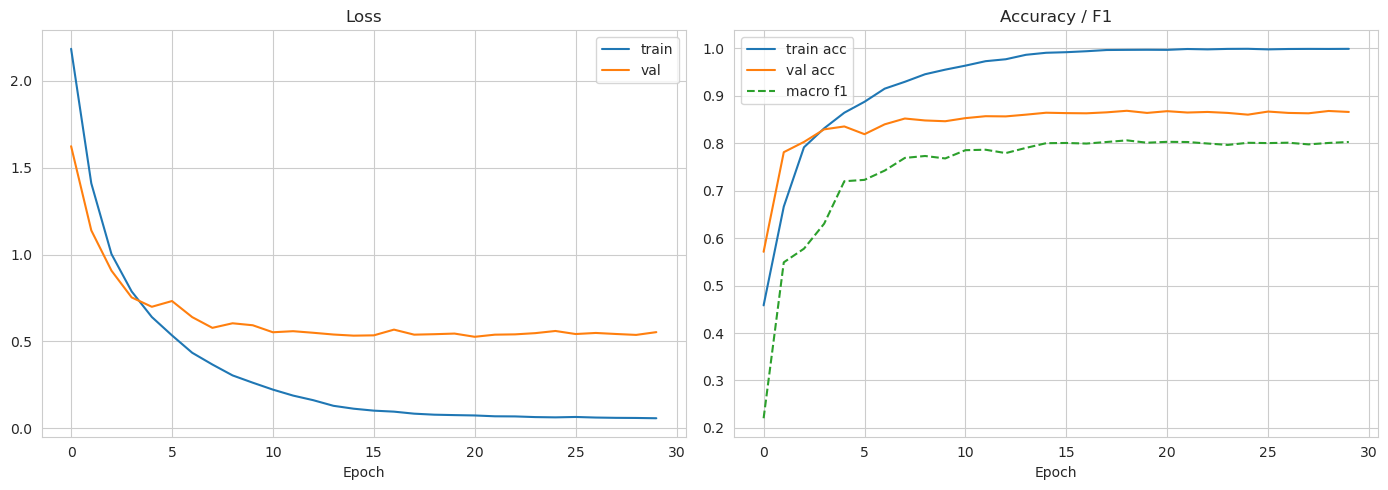

In [125]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history['train_acc'], label='train acc')
ax[1].plot(history['val_acc'], label='val acc')
ax[1].plot(history['macro_f1'], label='macro f1', linestyle='--')
ax[1].set_title('Accuracy / F1')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

## 9. Classification Report

In [126]:
target_names = [EMOTION_LABELS[i] for i in range(CONFIG['num_classes'])]
print(classification_report(all_targets, all_preds, target_names=target_names, digits=4))

              precision    recall  f1-score   support

    Surprise     0.8880    0.8295    0.8577       258
        Fear     0.8049    0.5893    0.6804        56
     Disgust     0.6597    0.6643    0.6620       143
   Happiness     0.9481    0.9560    0.9520       955
     Sadness     0.8307    0.7909    0.8103       397
       Anger     0.9224    0.7589    0.8327       141
     Neutral     0.7955    0.9010    0.8449       505

    accuracy                         0.8680      2455
   macro avg     0.8356    0.7843    0.8057      2455
weighted avg     0.8698    0.8680    0.8672      2455



## 10. Confusion Matrices

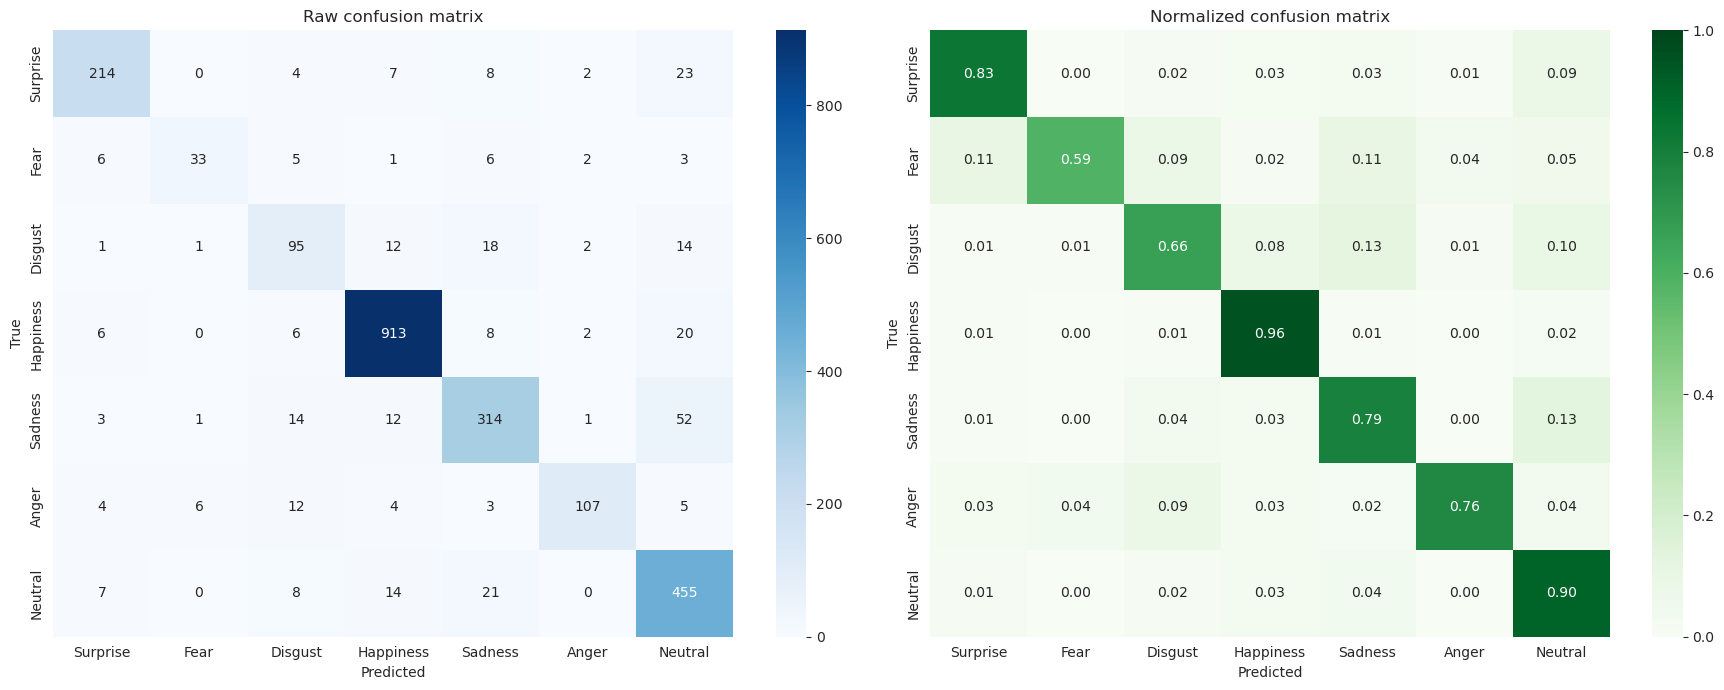

In [127]:
cm = confusion_matrix(all_targets, all_preds)
cm_norm = confusion_matrix(all_targets, all_preds, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax[0])
ax[0].set_title('Raw confusion matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, xticklabels=target_names, yticklabels=target_names, ax=ax[1])
ax[1].set_title('Normalized confusion matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 11. PCA and t-SNE of Features

These plots use the validation split features.

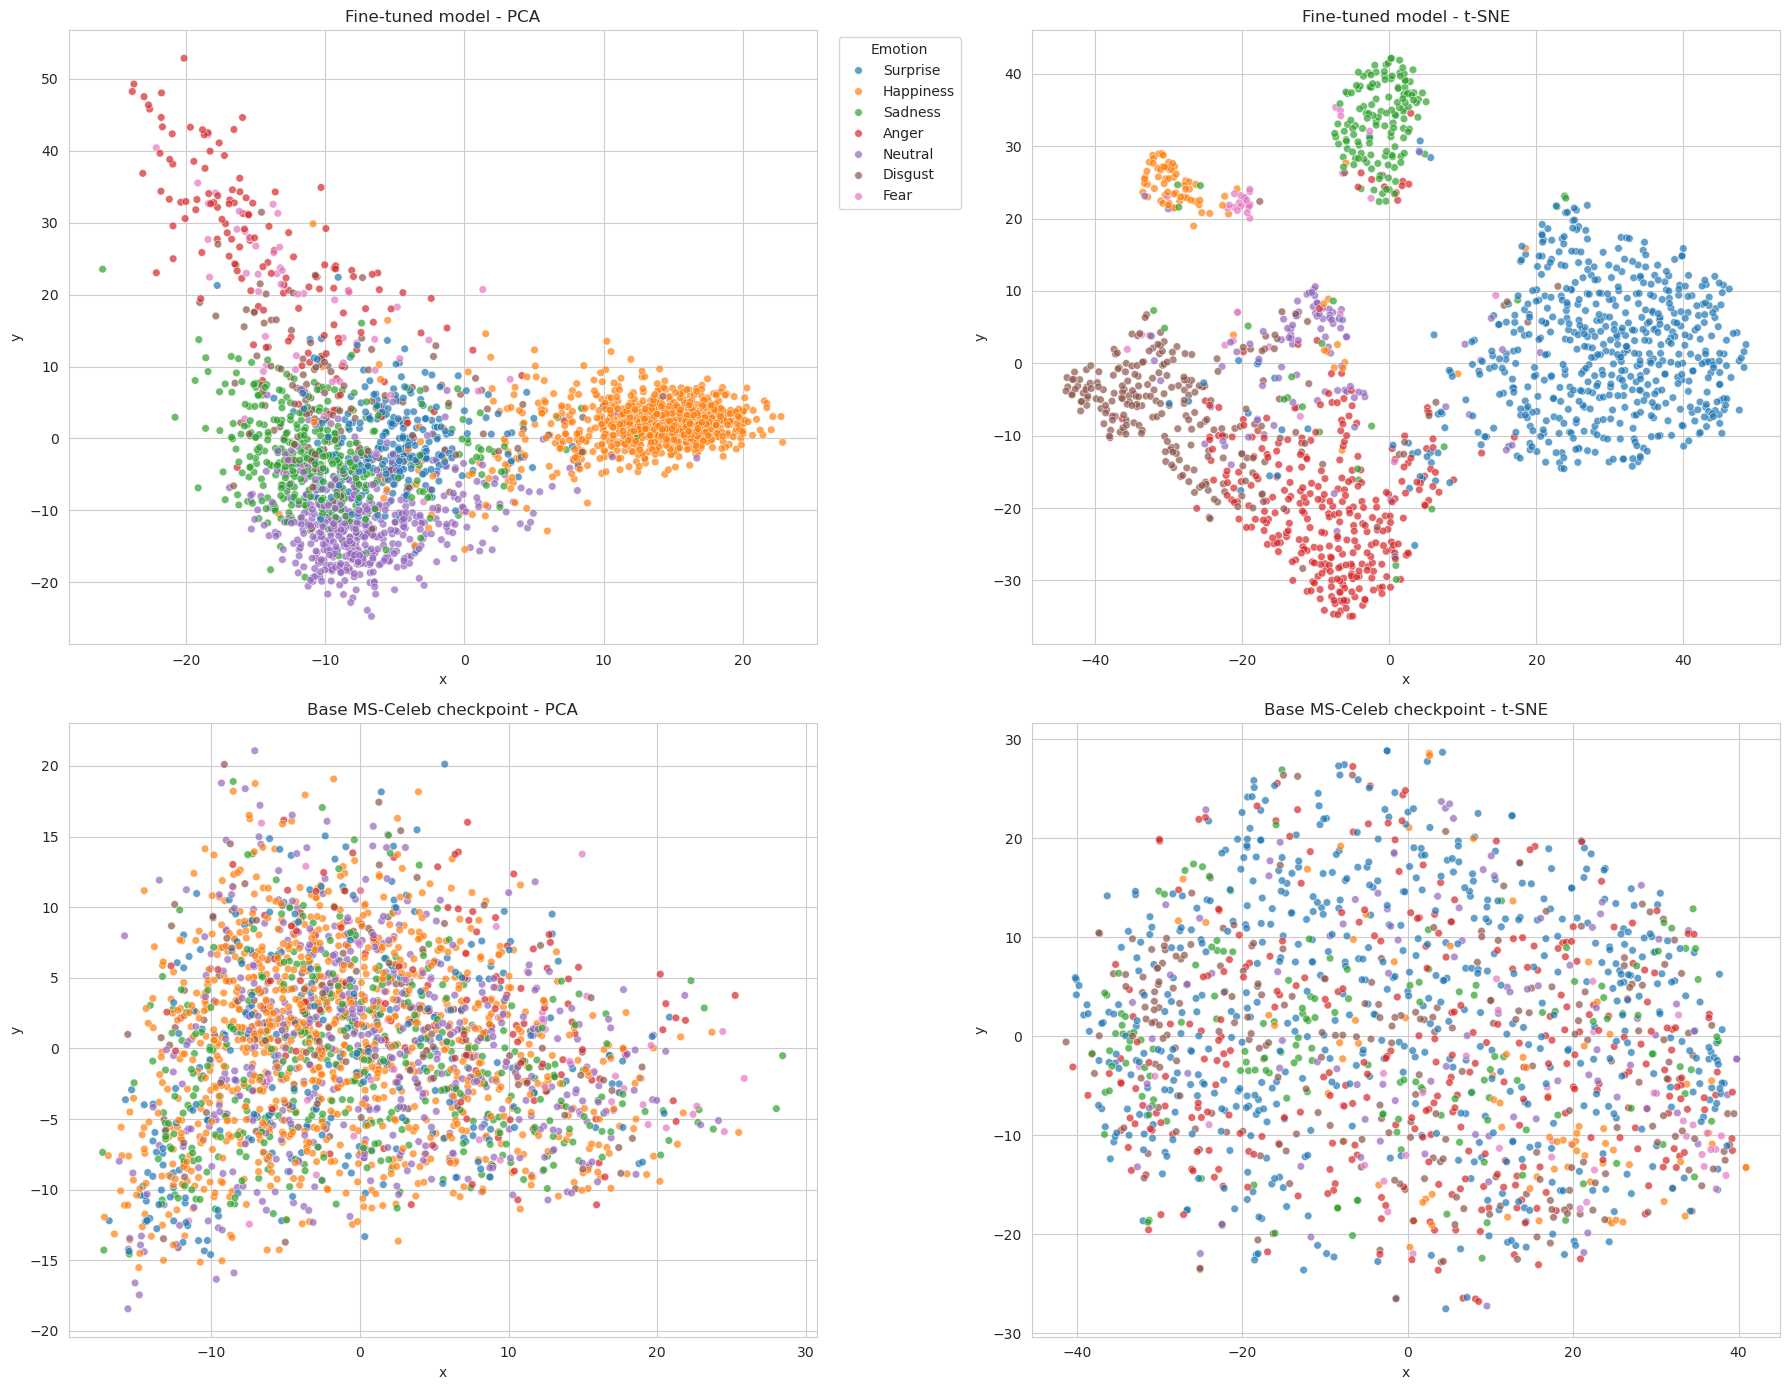

In [128]:
def collect_features(feature_model, loader):
    feature_model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in tqdm(loader, leave=False):
            feat, _ = feature_model(images.to(device))
            feats.append(feat.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)


def project_features(feats, labels, idx=None):
    feats = StandardScaler().fit_transform(feats)
    pca_xy = PCA(n_components=2, random_state=SEED).fit_transform(feats)

    if idx is None:
        n = min(CONFIG['max_tsne_samples'], len(feats))
        idx = np.random.default_rng(SEED).choice(len(feats), n, replace=False) if len(feats) > n else np.arange(len(feats))

    perplexity = min(30, max(5, len(idx) // 10), len(idx) - 1)
    tsne_xy = TSNE(
        n_components=2,
        perplexity=perplexity,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
    ).fit_transform(feats[idx])

    pca_df = pd.DataFrame({
        'x': pca_xy[:, 0],
        'y': pca_xy[:, 1],
        'label': [EMOTION_LABELS[int(i)] for i in labels],
    })
    tsne_df = pd.DataFrame({
        'x': tsne_xy[:, 0],
        'y': tsne_xy[:, 1],
        'label': [EMOTION_LABELS[int(i)] for i in labels[idx]],
    })
    return pca_df, tsne_df, idx


fine_tuned_features, labels = collect_features(model, val_loader)
n = min(CONFIG['max_tsne_samples'], len(fine_tuned_features))
idx = np.random.default_rng(SEED).choice(len(fine_tuned_features), n, replace=False) if len(fine_tuned_features) > n else np.arange(len(fine_tuned_features))
fine_pca_df, fine_tsne_df, idx = project_features(fine_tuned_features, labels, idx)

base_model = ResNet18AffinityModel(
    num_classes=CONFIG['num_classes'],
    hidden_dim=CONFIG['hidden_dim'],
    dropout=CONFIG['dropout'],
    checkpoint_path=backbone_checkpoint,
).to(device)
base_features, _ = collect_features(base_model, val_loader)
base_pca_df, base_tsne_df, _ = project_features(base_features, labels, idx)

fig, ax = plt.subplots(2, 2, figsize=(18, 14))

sns.scatterplot(data=fine_pca_df, x='x', y='y', hue='label', s=30, alpha=0.7, palette='tab10', ax=ax[0, 0])
ax[0, 0].set_title('Fine-tuned model - PCA')
ax[0, 0].legend(title='Emotion', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(data=fine_tsne_df, x='x', y='y', hue='label', s=30, alpha=0.7, palette='tab10', ax=ax[0, 1], legend=False)
ax[0, 1].set_title('Fine-tuned model - t-SNE')

sns.scatterplot(data=base_pca_df, x='x', y='y', hue='label', s=30, alpha=0.7, palette='tab10', ax=ax[1, 0], legend=False)
ax[1, 0].set_title('Base MS-Celeb checkpoint - PCA')

sns.scatterplot(data=base_tsne_df, x='x', y='y', hue='label', s=30, alpha=0.7, palette='tab10', ax=ax[1, 1], legend=False)
ax[1, 1].set_title('Base MS-Celeb checkpoint - t-SNE')

plt.tight_layout()
plt.show()

del base_model